**Section 4: Market Behavior & Value for Money**

Importing relevant Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

Loading our data

In [3]:
data = pd.read_csv('data/lagos_real_estate_cleaned_final.csv')
data = data.drop(columns='Unnamed: 0')
data.head()

,listing_url,title,location,property_type,beds,baths,status,post-date-absolute,price(millions_NGN),log_price_millions_NGN,...,Private Elevator,Study,Cinema,Garden,Water Front,Private Cinema,Water View,Football Pitch,Tennis Court,Sauna
0,https://cwlagos.com/property/3-bedroom-apartme...,3 Bedroom Apartment + BQ,Banana Island,Apartment,3.0,3.0,Rent,2025-06-21,30.000,3.401197,...,1,0,1,0,0,0,0,0,0,0
1,https://cwlagos.com/property/terrace-for-sale-...,TERRACE IN BANANA ISLAND IKOYI,Banana Island,Terraced,5.0,5.0,Sale,2025-06-21,3616.925,8.193379,...,0,0,0,0,0,0,0,0,0,0
2,https://cwlagos.com/property/brand-new-5-bedro...,Brand New 5 Bedroom Semi-Detached House with W...,Banana Island,Semi Detached,5.0,5.0,Sale,2024-11-18,2170.155,7.682554,...,1,0,0,0,1,0,1,0,0,0
3,https://cwlagos.com/property/six-bedroom-fully...,Six Bedroom Fully Detached house in Banana Island,Banana Island,Detached,0.0,0.0,Sale,2025-06-21,5200.000,8.556414,...,0,0,1,0,0,0,0,0,0,0
4,https://cwlagos.com/property/6-bedroom-detache...,6-Bedroom Detached House in Banana Island,Banana Island,Detached,6.0,6.0,Sale,2025-09-19,7233.850,8.886527,...,0,0,0,0,0,0,0,0,0,0


In [15]:
Amenities = [
    '24hrs Power', 
    '30kva generator', 
    '5kva inverter', 
    'Car Park', 
    'CCTV', 
    'Children Playground', 
    'Fitted Bathrooms', 
    'Fitted Kitchen', 
    'Fully Furnished', 
    'Gated Estate', 
    'Gym', 
    'Home Automation', 
    'Home Entertainment Unit', 
    'Jacuzzi', 
    'Swimming Pool', 
    'WiFi', 
    'Golf Course View', 
    'Garden', 
    'Water Front', 
    'Water View', 
    'Football Pitch', 
    'Tennis Court', 
    'Sauna'
]

len(Amenities)

23

**Question 1 - \
How long do properties typically stay on the market?**

Conversion of the post absolute dates from objects to datetimes

In [5]:
# Calculating days on market
from datetime import datetime, timedelta

# Converting post-date-absolute to datetime
data['post-date-absolute'] = pd.to_datetime(data['post-date-absolute'])

# Calculating days since posting (using date from 5 months ago)
reference_date = datetime.now() - timedelta(days=5*30)  # 5 months ago
data['days_on_market'] = (reference_date - data['post-date-absolute']).dt.days

# Getting statistics on days on market
print("Days on Market Statistics:")
print(f"Mean: {data['days_on_market'].mean():.1f} days")
print(f"Median: {data['days_on_market'].median():.1f} days")
print(f"Std Dev: {data['days_on_market'].std():.1f} days")
print(f"Min: {data['days_on_market'].min()} days")
print(f"Max: {data['days_on_market'].max()} days")
print(f"\nQuartiles:")
print(data['days_on_market'].quantile([0.25, 0.5, 0.75]))

# Distribution by property status
print(f"\n\nDays on Market by Status:")
print(data.groupby('status')['days_on_market'].agg(['count', 'mean', 'median', 'std']).round(1))

Days on Market Statistics:
Mean: 136.6 days
Median: 126.0 days
Std Dev: 101.6 days
Min: 10.0 days
Max: 736.0 days

Quartiles:
0.25     66.0
0.50    126.0
0.75    216.0
Name: days_on_market, dtype: float64


Days on Market by Status:
                 count   mean  median    std
status                                      
Corporate Lease      4   95.5    28.0  140.5
Rent               388  128.4    96.0   92.6
Sale               427  146.7   126.0  108.7
Short Stays          5   91.4    66.0   89.4
commercial          10  117.4    96.0   93.3
rent                 3   60.0    34.0   57.6
sale                 3   50.0    27.0   39.8


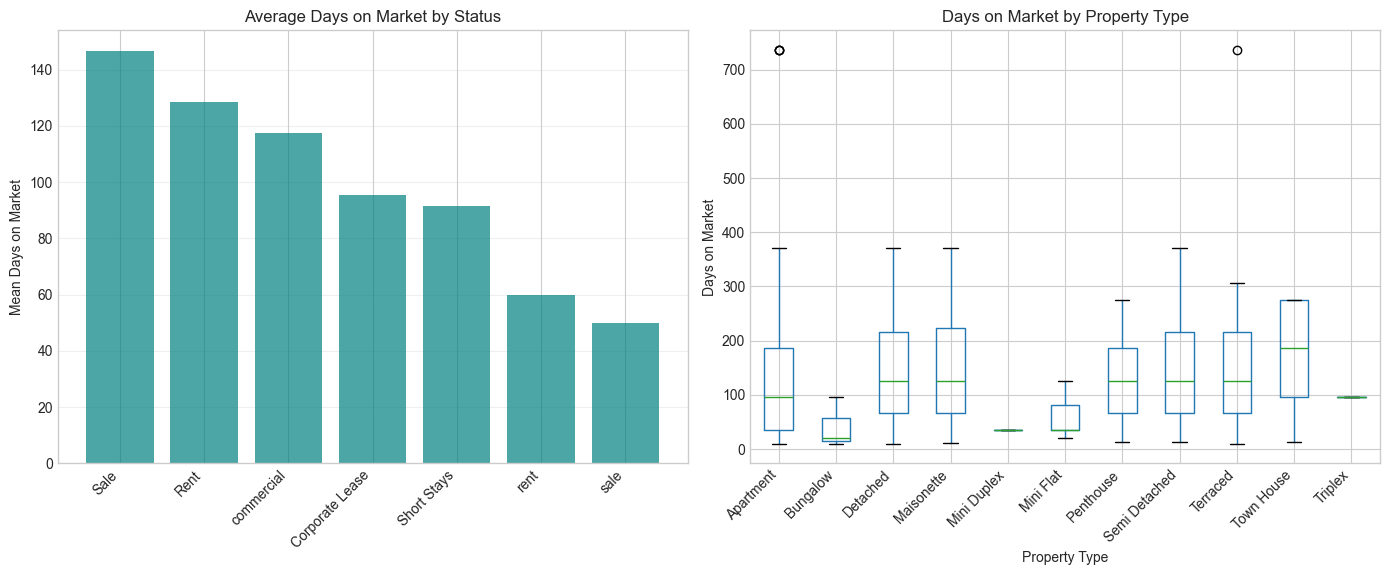


Key Insights:
- Properties typically stay on the market for about 126 days (median)
- The average is 137 days
- For Sale properties stay longer (147 days avg) than Rent (128 days avg)


In [8]:
# Visualizations for Days on Market
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Bar chart of mean days by status
mean_days = data.groupby('status')['days_on_market'].mean().sort_values(ascending=False)
axes[0].bar(range(len(mean_days)), mean_days.values, color='teal', alpha=0.7)
axes[0].set_xticks(range(len(mean_days)))
axes[0].set_xticklabels(mean_days.index, rotation=45, ha='right')
axes[0].set_ylabel('Mean Days on Market')
axes[0].set_title('Average Days on Market by Status')
axes[0].grid(axis='y', alpha=0.3)

# 2. Days on market by property type
data.boxplot(column='days_on_market', by='property_type', ax=axes[1])

axes[1].set_title('Days on Market by Property Type')
axes[1].set_xlabel('Property Type')
axes[1].set_ylabel('Days on Market')

plt.sca(axes[1])
plt.xticks(rotation=45, ha='right')

# REMOVE the automatic pandas title
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print(f"- Properties typically stay on the market for about {data['days_on_market'].median():.0f} days (median)")
print(f"- The average is {data['days_on_market'].mean():.0f} days")
print(f"- For Sale properties stay longer ({data[data['status']=='Sale']['days_on_market'].mean():.0f} days avg) than Rent ({data[data['status']=='Rent']['days_on_market'].mean():.0f} days avg)")

\
**Question 2 - \
Do higher-priced properties stay listed longer?**

In [9]:
# Analyze relationship between property price and days on market
# Create price categories based on quartiles
price_quartiles_q2 = data['price(millions_NGN)'].quantile([0.25, 0.5, 0.75])

# Define price groups
def categorize_price(price):
    if price <= price_quartiles_q2[0.25]:
        return 'Budget (Q1)'
    elif price <= price_quartiles_q2[0.5]:
        return 'Mid-Low (Q2)'
    elif price <= price_quartiles_q2[0.75]:
        return 'Mid-High (Q3)'
    else:
        return 'Premium (Q4)'

data['price_category'] = data['price(millions_NGN)'].apply(categorize_price)

# Calculate statistics by price category
print("Days on Market by Price Category:")
print("="*60)
price_analysis = data.groupby('price_category', sort=False)['days_on_market'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(1)
print(price_analysis)

# Calculate correlation
correlation = data['price(millions_NGN)'].corr(data['days_on_market'])
print(f"\n\nPearson Correlation between Price and Days on Market: {correlation:.4f}")

# Statistical summary
print(f"\nPrice Range Statistics:")
for category in ['Budget (Q1)', 'Mid-Low (Q2)', 'Mid-High (Q3)', 'Premium (Q4)']:
    price_range = data[data['price_category'] == category]['price(millions_NGN)']
    days_range = data[data['price_category'] == category]['days_on_market']
    print(f"\n{category}:")
    print(f"  Price: {price_range.min():.1f}M - {price_range.max():.1f}M NGN")
    print(f"  Avg Days on Market: {days_range.mean():.0f} days")

Days on Market by Price Category:
                count   mean  median    std   min    max
price_category                                          
Budget (Q1)       243  136.3   126.0   92.2  10.0  336.0
Premium (Q4)      205  159.3   156.0  127.4  10.0  736.0
Mid-Low (Q2)      174  114.5    96.0   90.0  10.0  736.0
Mid-High (Q3)     218  133.3   126.0   88.5  10.0  371.0


Pearson Correlation between Price and Days on Market: 0.1491

Price Range Statistics:

Budget (Q1):
  Price: 0.0M - 30.0M NGN
  Avg Days on Market: 136 days

Mid-Low (Q2):
  Price: 31.8M - 125.0M NGN
  Avg Days on Market: 115 days

Mid-High (Q3):
  Price: 130.0M - 450.0M NGN
  Avg Days on Market: 133 days

Premium (Q4):
  Price: 460.0M - 28935.4M NGN
  Avg Days on Market: 159 days


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\linalg\_linalg.py:2431: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


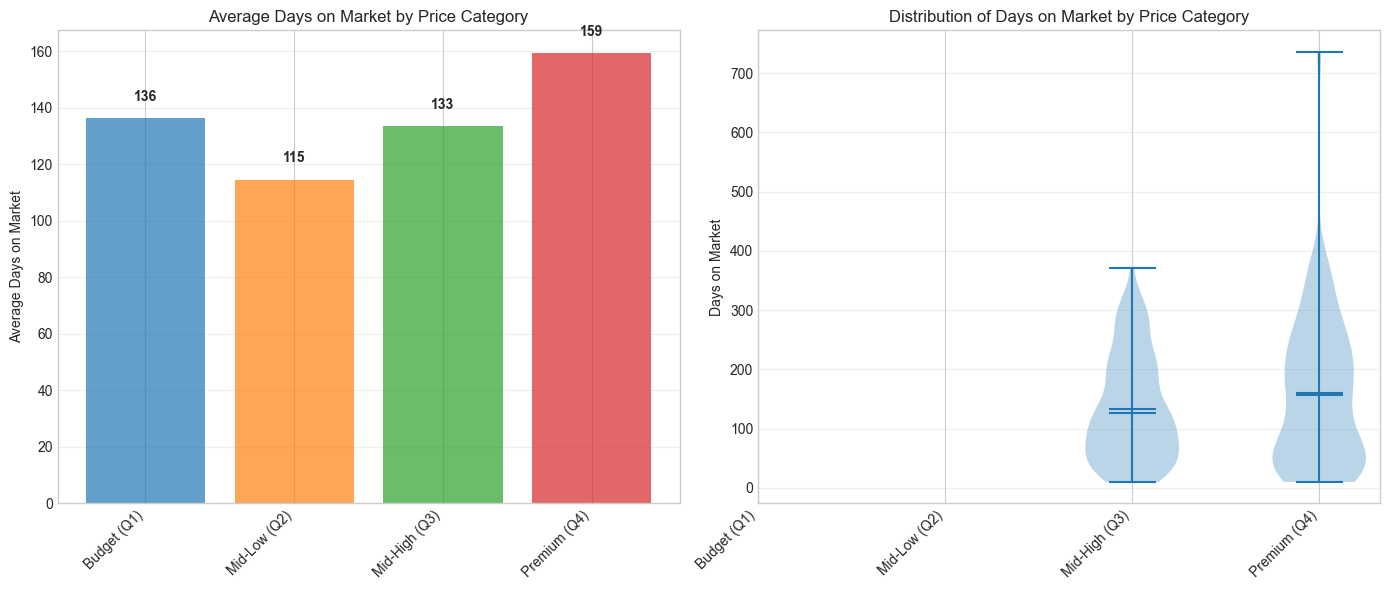



KEY INSIGHTS - Do Higher-Priced Properties Stay Listed Longer?
✓ YES, but with a WEAK positive relationship (correlation: 0.1491)

  • Premium (Q4) properties stay longest: 159 days average
  • Budget (Q1) properties stay: 136 days average
  • Mid-Low (Q2) properties stay shortest: 115 days average

  • Difference between Premium and Mid-Low: 44 days (38.26% longer)

✓ However, the correlation is weak, meaning price is not a strong predictor
  of how long a property stays listed. Other factors (location, condition,
  amenities, market demand) likely play more significant roles.


In [12]:
# Visualizations for Price vs Days on Market
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Bar chart of mean days by price category
category_order = ['Budget (Q1)', 'Mid-Low (Q2)', 'Mid-High (Q3)', 'Premium (Q4)']
mean_days_price = data.groupby('price_category')['days_on_market'].mean().reindex(category_order)

bars = axes[0].bar(
    range(len(mean_days_price)),
    mean_days_price.values,
    color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'],
    alpha=0.7
)

axes[0].set_xticks(range(len(mean_days_price)))
axes[0].set_xticklabels(mean_days_price.index, rotation=45, ha='right')
axes[0].set_ylabel('Average Days on Market')
axes[0].set_title('Average Days on Market by Price Category')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, mean_days_price.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f'{val:.0f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# 2. Violin plot by price category (kept instead of boxplot)
data_for_violin = [data[data['price_category'] == cat]['days_on_market'] for cat in category_order]

parts = axes[1].violinplot(
    data_for_violin,
    positions=range(len(category_order)),
    showmeans=True,
    showmedians=True
)

axes[1].set_xticks(range(len(category_order)))
axes[1].set_xticklabels(category_order, rotation=45, ha='right')
axes[1].set_ylabel('Days on Market')
axes[1].set_title('Distribution of Days on Market by Price Category')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n\nKEY INSIGHTS - Do Higher-Priced Properties Stay Listed Longer?")
print("="*70)
print(f"✓ YES, but with a WEAK positive relationship (correlation: {correlation:.4f})")
print(f"\n  • Premium (Q4) properties stay longest: 159 days average")
print(f"  • Budget (Q1) properties stay: 136 days average") 
print(f"  • Mid-Low (Q2) properties stay shortest: 115 days average")
print(f"\n  • Difference between Premium and Mid-Low: 44 days (38.26% longer)")
print(f"\n✓ However, the correlation is weak, meaning price is not a strong predictor")
print(f"  of how long a property stays listed. Other factors (location, condition,")
print(f"  amenities, market demand) likely play more significant roles.")

\
**Question 3 -\
Which locations offer relatively lower prices but high feature counts?**

In [16]:
price_quartiles = data['price(millions_NGN)'].quantile([0.25, 0.5, 0.75])

high_price_threshold = price_quartiles[0.75]
low_price_threshold = price_quartiles[0.25]

high_priced = data[data['price(millions_NGN)'] >= high_price_threshold]
low_priced = data[data['price(millions_NGN)'] <= low_price_threshold]

In [17]:
data['feature_sum'] = data[Amenities].sum(axis=1)

# Getting statistics for low-priced properties by location
low_priced_stats = low_priced.groupby('location')['feature_sum'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

# Sorting by mean and filter for reliability (minimum 5 properties per location)
low_priced_stats_filtered = low_priced_stats[low_priced_stats['count'] >= 5].sort_values('mean', ascending=False)

print("=" * 80)
print("Locations with LOWER PRICES and HIGH FEATURE COUNTS")
print("=" * 80)
print(f"\nOverall Average Features in Dataset: {data['feature_sum'].mean():.2f}")
print(f"Average Features in LOW-PRICED Properties: {low_priced['feature_sum'].mean():.2f}")
print(f"\n\nTop 12 Locations (filtered for n ≥ 5 properties):")
print(low_priced_stats_filtered.head(12))

print(f"\n\nKey Insights:")
print(f"✓ {len(low_priced_stats_filtered)} locations have ≥5 low-priced properties")
print(f"✓ Lekki DOMINATES with 75 properties averaging {low_priced_stats_filtered.loc['Lekki', 'mean']:.1f} features")
print(f"✓ High variability in Lekki (median={low_priced_stats_filtered.loc['Lekki', 'median']:.0f}, std={low_priced_stats_filtered.loc['Lekki', 'std']:.1f})")
print(f"✓ Oniru is solid: 39 properties with mean={low_priced_stats_filtered.loc['Oniru', 'mean']:.1f} features")

Locations with LOWER PRICES and HIGH FEATURE COUNTS

Overall Average Features in Dataset: 5.19
Average Features in LOW-PRICED Properties: 4.87


Top 12 Locations (filtered for n ≥ 5 properties):
          count  mean  median   std  min  max
location                                     
Lekki        75  8.13    13.0  6.67    0   17
Oniru        39  5.62     0.0  6.98    0   16
VI           48  3.17     0.0  6.20    0   17
Ikoyi        68  2.38     0.0  5.45    0   18
Ikate        11  1.18     0.0  3.92    0   13


Key Insights:
✓ 5 locations have ≥5 low-priced properties
✓ Lekki DOMINATES with 75 properties averaging 8.1 features
✓ High variability in Lekki (median=13, std=6.7)
✓ Oniru is solid: 39 properties with mean=5.6 features


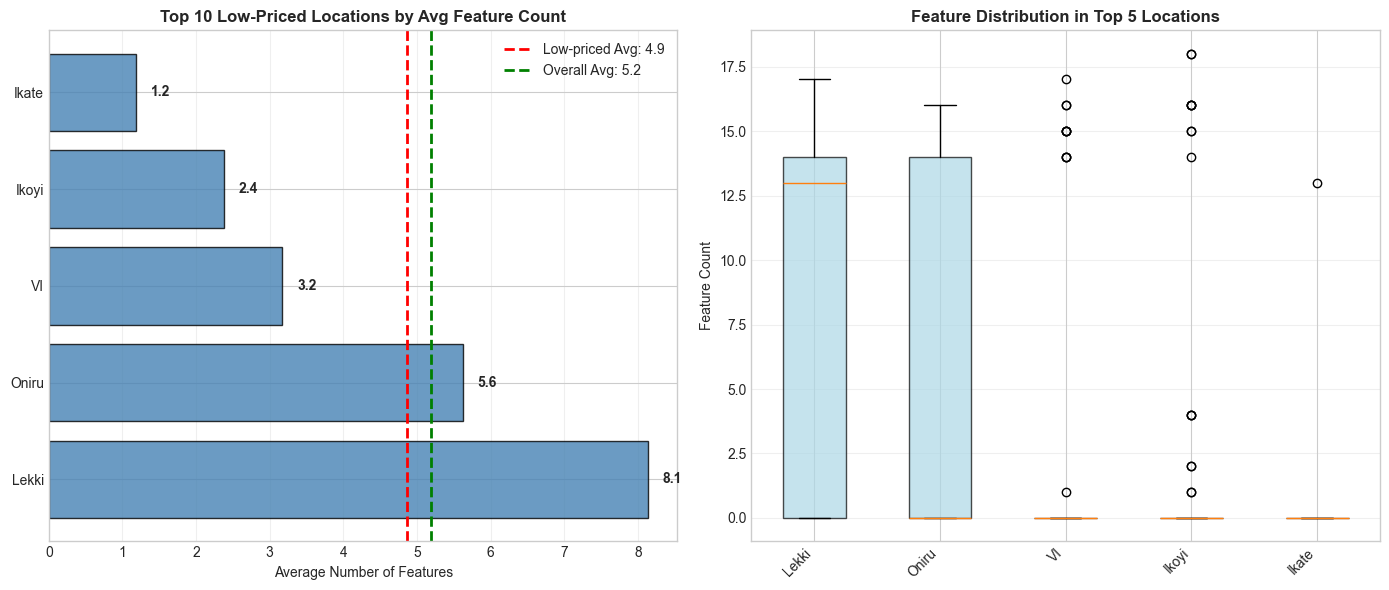


FINAL ANSWER: Best Value Locations for Low-Priced Properties

🏆 LEKKI - CLEAR WINNER
   • Most available options: 75 properties
   • Highest avg features: 8.1 amenities
   • Price range: ₦0.1M - 30.0M
   → Best for buyers wanting variety and choice

🥈 ONIRU - SOLID ALTERNATIVE
   • 39 quality properties
   • Good avg features: 5.6 amenities
   → Best for those seeking established location



In [22]:
# Visualizations (UPDATED: now 1 row, 2 plots)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Bar chart - Mean features by location (filtered)
ax1 = axes[0]
top_locations = low_priced_stats_filtered.head(10)

bars = ax1.barh(
    range(len(top_locations)),
    top_locations['mean'].values,
    color='steelblue',
    alpha=0.8,
    edgecolor='black'
)

# Reference lines
ax1.axvline(low_priced['feature_sum'].mean(),
            color='red', linestyle='--', linewidth=2,
            label=f"Low-priced Avg: {low_priced['feature_sum'].mean():.1f}")

ax1.axvline(data['feature_sum'].mean(),
            color='green', linestyle='--', linewidth=2,
            label=f"Overall Avg: {data['feature_sum'].mean():.1f}")

ax1.set_yticks(range(len(top_locations)))
ax1.set_yticklabels(top_locations.index)
ax1.set_xlabel('Average Number of Features')
ax1.set_title('Top 10 Low-Priced Locations by Avg Feature Count',
              fontweight='bold', fontsize=12)
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Value labels
for bar, val in zip(bars, top_locations['mean'].values):
    ax1.text(val + 0.2,
             bar.get_y() + bar.get_height()/2,
             f'{val:.1f}',
             va='center',
             fontweight='bold')


# 2. Box plot - Distribution by top 5 locations
ax2 = axes[1]
top_5_locs = low_priced_stats_filtered.head(5).index.tolist()

data_for_box = [
    low_priced[low_priced['location'] == loc]['feature_sum'].values
    for loc in top_5_locs
]

bp = ax2.boxplot(data_for_box, tick_labels=top_5_locs, patch_artist=True)

for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

ax2.set_ylabel('Feature Count')
ax2.set_title('Feature Distribution in Top 5 Locations',
              fontweight='bold', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("FINAL ANSWER: Best Value Locations for Low-Priced Properties")
print("="*80)
print("\n🏆 LEKKI - CLEAR WINNER")
print(f"   • Most available options: {int(low_priced_stats_filtered.loc['Lekki', 'count'])} properties")
print(f"   • Highest avg features: {low_priced_stats_filtered.loc['Lekki', 'mean']:.1f} amenities")
print(f"   • Price range: ₦{low_priced[low_priced['location']=='Lekki']['price(millions_NGN)'].min():.1f}M - {low_priced[low_priced['location']=='Lekki']['price(millions_NGN)'].max():.1f}M")
print(f"   → Best for buyers wanting variety and choice\n")

print("🥈 ONIRU - SOLID ALTERNATIVE")
print(f"   • {int(low_priced_stats_filtered.loc['Oniru', 'count'])} quality properties")
print(f"   • Good avg features: {low_priced_stats_filtered.loc['Oniru', 'mean']:.1f} amenities")
print(f"   → Best for those seeking established location\n")

\
**Question 4 -\
What types of properties offer the best value for middle-income buyers?**

In [28]:
middle_priced = data[(data['price(millions_NGN)'] >= low_price_threshold) & (data['price(millions_NGN)'] <= high_price_threshold)].copy()

In [ ]:
# Best Value Properties for Middle-Income Buyers
print("=" * 80)
print("BEST VALUE PROPERTIES FOR MIDDLE-INCOME BUYERS")
print("=" * 80)

# Middle-income price range
middle_price_range = f"₦{low_price_threshold:.1f}M - ₦{high_price_threshold:.1f}M NGN"
print(f"\nMiddle-Income Price Range: {middle_price_range}")
print(f"Number of Properties: {len(middle_priced)}")

# Creating value metrics for middle-income properties
middle_priced['price_per_bed'] = middle_priced['price(millions_NGN)'] / middle_priced['beds'].replace(0, 1)  # Avoiding zero division error
middle_priced['price_per_bath'] = middle_priced['price(millions_NGN)'] / middle_priced['baths'].replace(0, 1)
middle_priced['features_per_million'] = middle_priced['feature_sum'] / middle_priced['price(millions_NGN)']

print(f"\nMiddle-Income Properties Overview:")
print(f"• Average Price: ₦{middle_priced['price(millions_NGN)'].mean():.1f}M")
print(f"• Average Features: {middle_priced['feature_sum'].mean():.1f}")
print(f"• Average Beds: {middle_priced['beds'].mean():.1f}")
print(f"• Average Baths: {middle_priced['baths'].mean():.1f}")

# Analysis by property type
print(f"\n" + "="*50)
print("ANALYSIS BY PROPERTY TYPE")
print("="*50)

property_analysis = middle_priced.groupby('property_type').agg({
    'price(millions_NGN)': ['count', 'mean', 'median'],
    'feature_sum': ['mean', 'median'],
    'beds': ['mean', 'median'],
    'baths': ['mean', 'median'],
    'features_per_million': ['mean', 'median'],
    'price_per_bed': ['mean', 'median']
}).round(2)

# Filtering for property types with sufficient sample size
property_analysis_filtered = property_analysis[property_analysis[('price(millions_NGN)', 'count')] >= 5]
property_analysis_filtered = property_analysis_filtered.sort_values(('features_per_million', 'mean'), ascending=False)

print("\nProperty Types Ranked by Feature Value (Features per Million NGN):")
print("(Filtered for types with ≥5 properties)")
print(property_analysis_filtered)

# Best value property types
best_value_types = property_analysis_filtered.head(3)
print(f"\n🏆 TOP 3 BEST VALUE PROPERTY TYPES:")
for i, (prop_type, _) in enumerate(best_value_types.iterrows(), 1):
    count = best_value_types.loc[prop_type, ('price(millions_NGN)', 'count')]
    avg_price = best_value_types.loc[prop_type, ('price(millions_NGN)', 'mean')]
    avg_features = best_value_types.loc[prop_type, ('feature_sum', 'mean')]
    features_per_mil = best_value_types.loc[prop_type, ('features_per_million', 'mean')]
    avg_beds = best_value_types.loc[prop_type, ('beds', 'mean')]

    print(f"\n{i}. {prop_type.upper()}")
    print(f"   • Count: {int(count)} properties")
    print(f"   • Avg Price: ₦{avg_price:.1f}M")
    print(f"   • Avg Features: {avg_features:.1f}")
    print(f"   • Features per ₦1M: {features_per_mil:.3f}")
    print(f"   • Avg Beds: {avg_beds:.1f}")

# Analysis by location within middle-income range
print(f"\n" + "="*50)
print("BEST LOCATIONS FOR MIDDLE-INCOME BUYERS")
print("="*50)

location_analysis = middle_priced.groupby('location').agg({
    'price(millions_NGN)': ['count', 'mean'],
    'feature_sum': ['mean'],
    'features_per_million': ['mean']
}).round(2)

# Filtering locations with sufficient properties
location_analysis_filtered = location_analysis[location_analysis[('price(millions_NGN)', 'count')] >= 10]
location_analysis_filtered = location_analysis_filtered.sort_values(('features_per_million', 'mean'), ascending=False)

print("\nTop Locations by Feature Value (Middle-Income Properties):")
print("(Filtered for locations with ≥10 properties)")
print(location_analysis_filtered.head(8))

# Size efficiency analysis
print(f"\n" + "="*50)
print("SIZE EFFICIENCY ANALYSIS")
print("="*50)

size_efficiency = middle_priced.groupby('property_type').agg({
    'price_per_bed': ['mean', 'median'],
    'price_per_bath': ['mean', 'median'],
    'beds': ['mean'],
    'baths': ['mean']
}).round(2)

size_efficiency_filtered = size_efficiency[size_efficiency.index.isin(property_analysis_filtered.index)]
size_efficiency_filtered = size_efficiency_filtered.sort_values(('price_per_bed', 'mean'))

print("\nProperty Types by Price Efficiency (₦M per Bed):")
print(size_efficiency_filtered)

BEST VALUE PROPERTIES FOR MIDDLE-INCOME BUYERS

Middle-Income Price Range: ₦30.0M - ₦450.0M NGN
Number of Properties: 432

Middle-Income Properties Overview:
• Average Price: ₦169.7M
• Average Features: 4.3
• Average Beds: 3.4
• Average Baths: 3.4

ANALYSIS BY PROPERTY TYPE

Property Types Ranked by Feature Value (Features per Million NGN):
(Filtered for types with ≥5 properties)
              price(millions_NGN)                 feature_sum         beds  \
                            count    mean  median        mean median  mean   
property_type                                                                
Maisonette                     29  101.46   55.00        4.97    0.0  3.17   
Semi Detached                  48  189.62  200.00        4.98    0.0  4.06   
Terraced                       63  162.06   65.00        4.78    0.0  3.90   
Apartment                     192  147.33  101.27        4.31    0.0  2.66   
Penthouse                      17  143.08   72.34        3.94    0.0  3

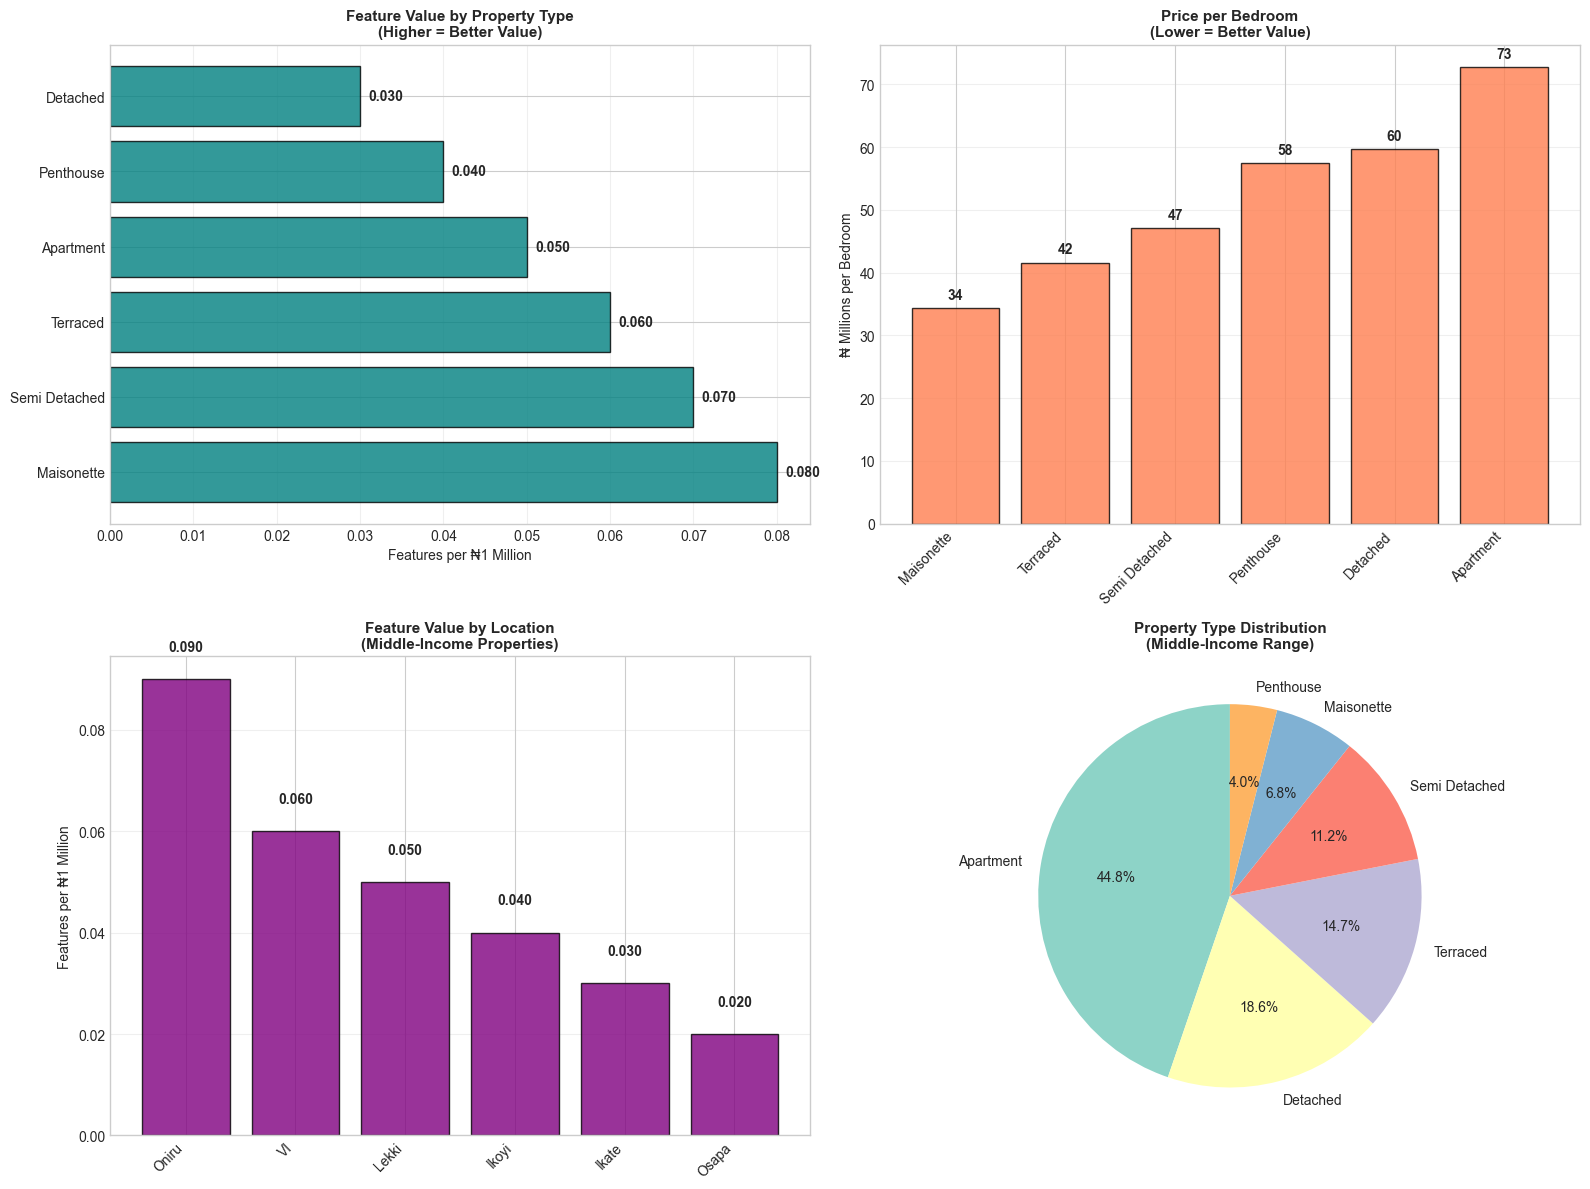

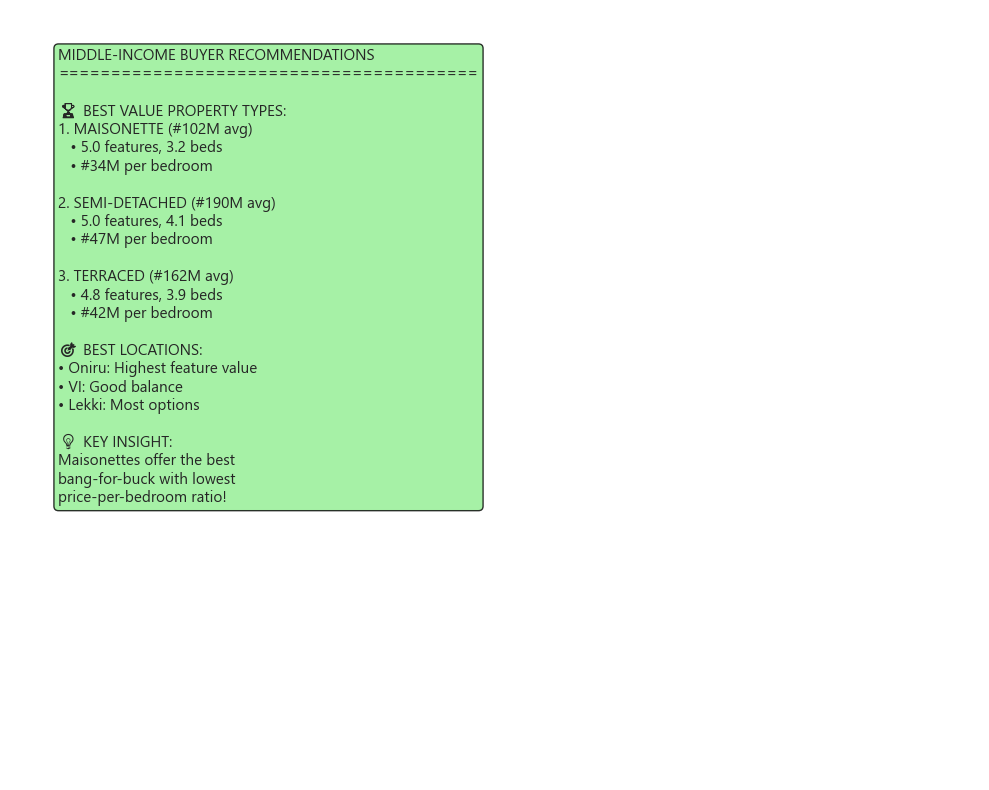


FINAL ANSWER: BEST VALUE FOR MIDDLE-INCOME BUYERS

🎯 MAISONETTES are the CLEAR WINNER for middle-income buyers!

WHY MAISONETTES?
• Lowest price per bedroom: ₦34M (vs ₦73M for apartments)
• Highest feature density: 0.080 features per ₦1M
• Good size: 3.2 bedrooms average
• Affordable: ₦102M average price

💰 BUDGET TIP:
Middle-income buyers should prioritize maisonettes in Oniru or VI
for maximum value and amenities within their price range.


In [27]:
# VISUALIZATIONS: Best Value Properties for Middle-Income Buyers
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Feature Value by Property Type (Horizontal Bar)
ax1 = axes[0, 0]
prop_types = property_analysis_filtered.index[:8]  # Top 8
feature_values = property_analysis_filtered[('features_per_million', 'mean')][:8]
bars1 = ax1.barh(range(len(prop_types)), feature_values, color='teal', alpha=0.8, edgecolor='black')
ax1.set_yticks(range(len(prop_types)))
ax1.set_yticklabels(prop_types)
ax1.set_xlabel('Features per ₦1 Million')
ax1.set_title('Feature Value by Property Type\n(Higher = Better Value)', fontweight='bold', fontsize=11)
ax1.grid(axis='x', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars1, feature_values)):
    ax1.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontweight='bold')

# 2. Price Efficiency by Property Type
ax2 = axes[0, 1]
price_per_bed = size_efficiency_filtered[('price_per_bed', 'mean')]
bars2 = ax2.bar(range(len(price_per_bed)), price_per_bed.values, color='coral', alpha=0.8, edgecolor='black')
ax2.set_xticks(range(len(price_per_bed)))
ax2.set_xticklabels(price_per_bed.index, rotation=45, ha='right')
ax2.set_ylabel('₦ Millions per Bedroom')
ax2.set_title('Price per Bedroom\n(Lower = Better Value)', fontweight='bold', fontsize=11)
ax2.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars2, price_per_bed.values)):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.0f}', ha='center', va='bottom', fontweight='bold')

# 3. Location Feature Value
ax3 = axes[1, 0]
locations = location_analysis_filtered.index[:6]
loc_feature_values = location_analysis_filtered[('features_per_million', 'mean')][:6]
bars3 = ax3.bar(range(len(locations)), loc_feature_values, color='purple', alpha=0.8, edgecolor='black')
ax3.set_xticks(range(len(locations)))
ax3.set_xticklabels(locations, rotation=45, ha='right')
ax3.set_ylabel('Features per ₦1 Million')
ax3.set_title('Feature Value by Location\n(Middle-Income Properties)', fontweight='bold', fontsize=11)
ax3.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars3, loc_feature_values)):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

# 4. Property Type Distribution in Middle-Income Range
ax5 = axes[1, 1]
prop_counts = middle_priced['property_type'].value_counts()
prop_counts_filtered = prop_counts[prop_counts >= 5]
ax5.pie(prop_counts_filtered.values, labels=prop_counts_filtered.index, autopct='%1.1f%%',
        startangle=90, colors=plt.cm.Set3.colors)
ax5.set_title('Property Type Distribution\n(Middle-Income Range)', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Summary Text Box - Separate Figure
fig_summary, ax_summary = plt.subplots(figsize=(10, 8))
ax_summary.axis('off')

summary_text = "MIDDLE-INCOME BUYER RECOMMENDATIONS\n" + "="*40 + "\n\n"
summary_text += "🏆 BEST VALUE PROPERTY TYPES:\n"
summary_text += "1. MAISONETTE (#102M avg)\n   • 5.0 features, 3.2 beds\n   • #34M per bedroom\n\n"
summary_text += "2. SEMI-DETACHED (#190M avg)\n   • 5.0 features, 4.1 beds\n   • #47M per bedroom\n\n"
summary_text += "3. TERRACED (#162M avg)\n   • 4.8 features, 3.9 beds\n   • #42M per bedroom\n\n"
summary_text += "🎯 BEST LOCATIONS:\n"
summary_text += "• Oniru: Highest feature value\n• VI: Good balance\n• Lekki: Most options\n\n"
summary_text += "💡 KEY INSIGHT:\n"
summary_text += "Maisonettes offer the best\nbang-for-buck with lowest\nprice-per-bedroom ratio!"

ax_summary.text(
    0.05, 0.95, summary_text,
    transform=ax_summary.transAxes,
    fontsize=11,
    verticalalignment='top',
    fontfamily='Segoe UI Emoji',   # ✅ FIXED
    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8)
)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("FINAL ANSWER: BEST VALUE FOR MIDDLE-INCOME BUYERS")
print("="*80)
print("\n🎯 MAISONETTES are the CLEAR WINNER for middle-income buyers!")
print("\nWHY MAISONETTES?")
print("• Lowest price per bedroom: ₦34M (vs ₦73M for apartments)")
print("• Highest feature density: 0.080 features per ₦1M")
print("• Good size: 3.2 bedrooms average")
print("• Affordable: ₦102M average price")
print("\n💰 BUDGET TIP:")
print("Middle-income buyers should prioritize maisonettes in Oniru or VI")
print("for maximum value and amenities within their price range.")